# 1: Imports, Path Setup & Load Model

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import json
import pandas as pd

# Determine repo root directory (two levels up from notebooks/isabel/)
REPO_ROOT = Path.cwd().parents[1] if Path.cwd().name == "isabel" else Path.cwd()

# Path to saved Keras model inside the artifacts directory
MODEL_PATH = REPO_ROOT / "artifacts" / "gluten_guard_efficientnet_full.keras"

# Directory containing test images categorized in subfolders
DATA_DIR = Path(
    "/home/isabelksommerfeld/code/lrnzgll/gluten-guard/data/"
    "food-101-predict-images-40-classes/food-101-predict-images-40-classes/"
)

# Validate that paths exist
assert MODEL_PATH.exists(), f"Model file not found at: {MODEL_PATH}"
assert DATA_DIR.exists(), f"Data directory not found at: {DATA_DIR}"

# Load trained EfficientNet model
print(f"Loading model from: {MODEL_PATH}")
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")

Loading model from: /home/isabelksommerfeld/code/lrnzgll/gluten-guard/artifacts/gluten_guard_efficientnet_full.keras
Model loaded successfully!


# 2: Infer Class Names & Define Prediction Function

In [ ]:
# Try to load class names from artifacts JSON if available
CLASSES_PATH = REPO_ROOT / "artifacts" / "class_names.json"

if CLASSES_PATH.exists():
    data = json.loads(CLASSES_PATH.read_text())
    class_names = data["class_names"] if isinstance(data, dict) else data
else:
    # Full list of 101 Food-101 classes in standard alphabetical order
    class_names = [
        'apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare',
        'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito',
        'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake',
        'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla',
        'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder',
        'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes',
        'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict',
        'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras',
        'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice',
        'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich',
        'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup',
        'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna',
        'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', 'miso_soup',
        'mussels', 'nachos', 'omelette', 'onion_rings', 'oysters',
        'pad_thai', 'paella', 'pancakes', 'panna_cotta', 'peking_duck',
        'pho', 'pizza', 'pork_chop', 'poutine', 'prime_rib',
        'pulled_pork_sandwich', 'ramen', 'ravioli', 'red_velvet_cake', 'risotto',
        'samosa', 'sashimi', 'scallops', 'seaweed_salad', 'shrimp_and_grits',
        'spaghetti_bolognese', 'spaghetti_carbonara', 'spring_rolls', 'steak', 'strawberry_shortcake',
        'sushi', 'tacos', 'takoyaki', 'tiramisu', 'tuna_tartare', 'waffles'
    ]

print(f"Loaded {len(class_names)} class names.")

def predict_image_top_k(image_path: Path, k: int = 3):
    """
    Load and preprocess an image, then return top-k predictions across all 101 classes.
    Note: EfficientNet's preprocessing is built into the model, so input images
    remain in standard [0, 255] float32 scale.
    """
    img = Image.open(image_path).convert("RGB").resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    img_batch = np.expand_dims(img_array, axis=0)  # Shape: (1, 224, 224, 3)

    probabilities = model.predict(img_batch, verbose=0)[0]

    # Sort probabilities to get top-k predicted indices
    top_indices = np.argsort(probabilities)[::-1][:k]

    results = [(class_names[idx], probabilities[idx]) for idx in top_indices]
    return img, results

Loaded 101 class names.


# 3 Test Predictions & Display Results

Testing 1 sample image from each of the 40 test subfolders...



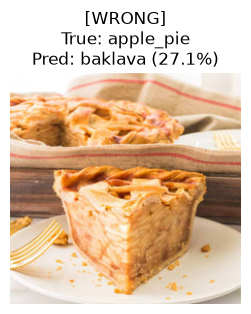

File: apple_pie_2.jpg
True Class: apple_pie
Top-3 Predictions:
  1. baklava                   27.12%
  2. grilled_cheese_sandwich   19.49%
  3. chicken_quesadilla        14.62%
--------------------------------------------------


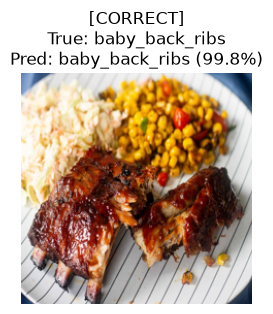

File: bb_ribs_4.jpg
True Class: baby_back_ribs
Top-3 Predictions:
  1. baby_back_ribs            99.76%
  2. pork_chop                 0.14%
  3. steak                     0.04%
--------------------------------------------------


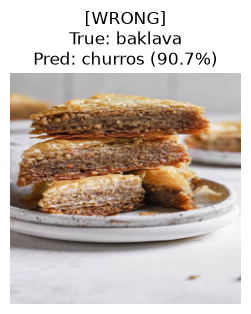

File: bak_5.jpg
True Class: baklava
Top-3 Predictions:
  1. churros                   90.66%
  2. french_toast              6.97%
  3. beignets                  0.95%
--------------------------------------------------


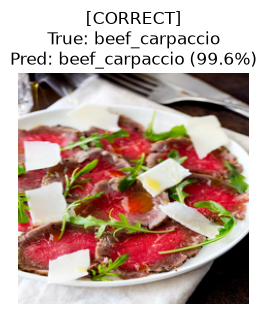

File: beef_car_5.jpg
True Class: beef_carpaccio
Top-3 Predictions:
  1. beef_carpaccio            99.64%
  2. peking_duck               0.28%
  3. tuna_tartare              0.02%
--------------------------------------------------


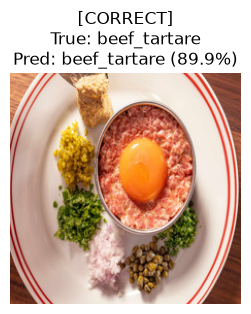

File: beef_tar_2.jpg
True Class: beef_tartare
Top-3 Predictions:
  1. beef_tartare              89.86%
  2. fried_rice                3.36%
  3. tuna_tartare              2.15%
--------------------------------------------------


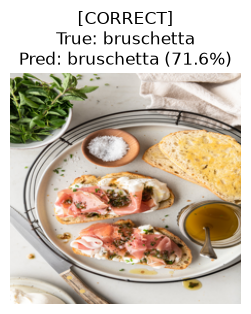

File: bruschetta_2.jpg
True Class: bruschetta
Top-3 Predictions:
  1. bruschetta                71.57%
  2. omelette                  4.28%
  3. grilled_salmon            3.56%
--------------------------------------------------


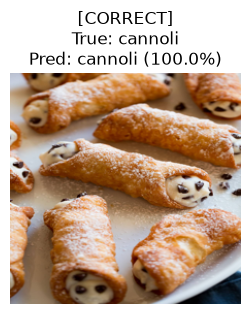

File: cannoli-2.jpg
True Class: cannoli
Top-3 Predictions:
  1. cannoli                   100.00%
  2. sushi                     0.00%
  3. spring_rolls              0.00%
--------------------------------------------------


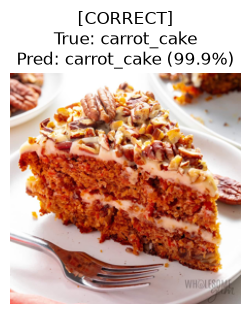

File: carrot_cake_2.jpg
True Class: carrot_cake
Top-3 Predictions:
  1. carrot_cake               99.86%
  2. red_velvet_cake           0.03%
  3. chocolate_cake            0.02%
--------------------------------------------------


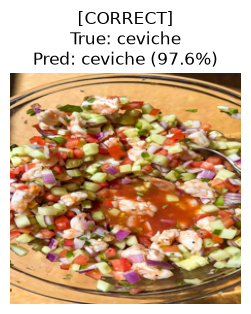

File: ceviche_1.jpg
True Class: ceviche
Top-3 Predictions:
  1. ceviche                   97.65%
  2. greek_salad               1.21%
  3. tacos                     0.51%
--------------------------------------------------


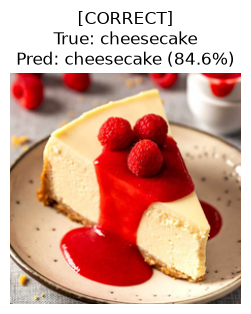

File: cheesecake-2.jpg
True Class: cheesecake
Top-3 Predictions:
  1. cheesecake                84.62%
  2. panna_cotta               9.20%
  3. strawberry_shortcake      2.89%
--------------------------------------------------


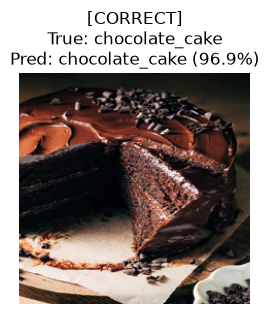

File: chocolate_cake_3.jpg
True Class: chocolate_cake
Top-3 Predictions:
  1. chocolate_cake            96.89%
  2. chocolate_mousse          3.09%
  3. tiramisu                  0.02%
--------------------------------------------------


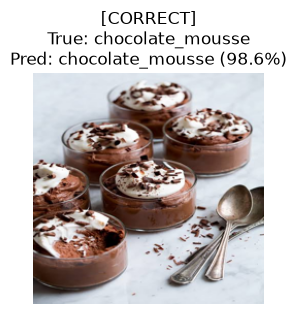

File: chocolate_mousse_2.jpg
True Class: chocolate_mousse
Top-3 Predictions:
  1. chocolate_mousse          98.63%
  2. chocolate_cake            1.09%
  3. ice_cream                 0.12%
--------------------------------------------------


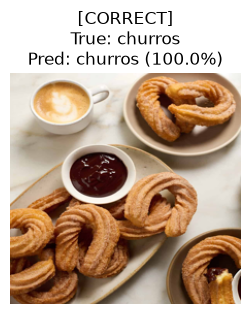

File: churros_4.jpg
True Class: churros
Top-3 Predictions:
  1. churros                   99.99%
  2. donuts                    0.01%
  3. onion_rings               0.00%
--------------------------------------------------


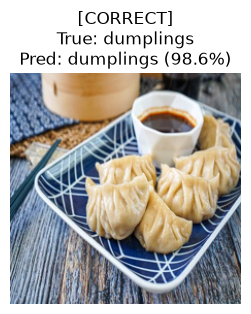

File: dumplings_2.jpg
True Class: dumplings
Top-3 Predictions:
  1. dumplings                 98.55%
  2. gyoza                     1.36%
  3. churros                   0.04%
--------------------------------------------------


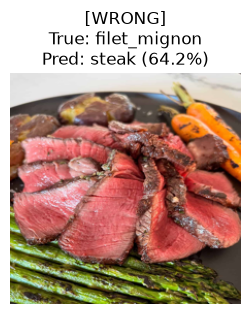

File: filet_mignon_2.jpg
True Class: filet_mignon
Top-3 Predictions:
  1. steak                     64.16%
  2. filet_mignon              33.62%
  3. prime_rib                 2.13%
--------------------------------------------------


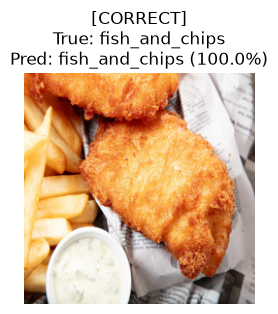

File: Fish_and_chips_2.jpg
True Class: fish_and_chips
Top-3 Predictions:
  1. fish_and_chips            100.00%
  2. chicken_wings             0.00%
  3. onion_rings               0.00%
--------------------------------------------------


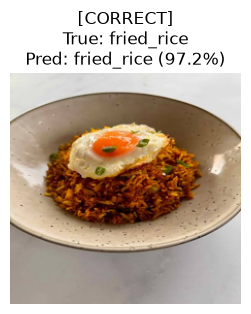

File: fried-rice-3.jpg
True Class: fried_rice
Top-3 Predictions:
  1. fried_rice                97.25%
  2. bibimbap                  2.03%
  3. paella                    0.35%
--------------------------------------------------


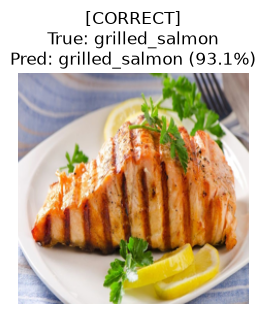

File: grilled_salmon_3.jpg
True Class: grilled_salmon
Top-3 Predictions:
  1. grilled_salmon            93.12%
  2. bruschetta                1.17%
  3. french_toast              1.11%
--------------------------------------------------


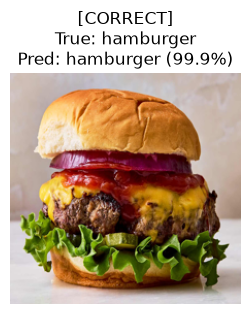

File: hamburger_1.jpg
True Class: hamburger
Top-3 Predictions:
  1. hamburger                 99.93%
  2. pulled_pork_sandwich      0.07%
  3. falafel                   0.00%
--------------------------------------------------


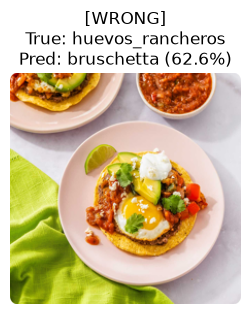

File: huevos-rancheros_1.jpg
True Class: huevos_rancheros
Top-3 Predictions:
  1. bruschetta                62.64%
  2. tacos                     13.93%
  3. huevos_rancheros          7.32%
--------------------------------------------------


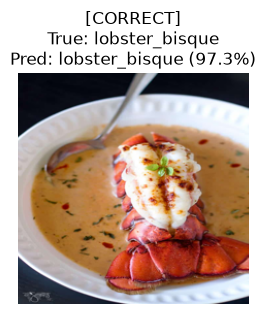

File: lobster-bisque_3.jpg
True Class: lobster_bisque
Top-3 Predictions:
  1. lobster_bisque            97.29%
  2. clam_chowder              1.68%
  3. chicken_curry             0.73%
--------------------------------------------------


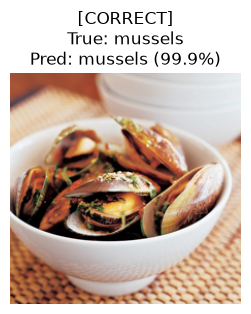

File: mussels_1.jpg
True Class: mussels
Top-3 Predictions:
  1. mussels                   99.94%
  2. beet_salad                0.01%
  3. escargots                 0.01%
--------------------------------------------------


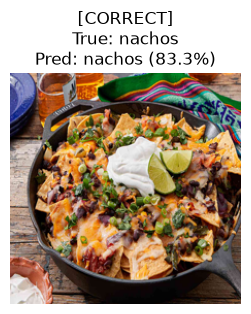

File: nachos_1.jpg
True Class: nachos
Top-3 Predictions:
  1. nachos                    83.33%
  2. paella                    13.55%
  3. huevos_rancheros          0.60%
--------------------------------------------------


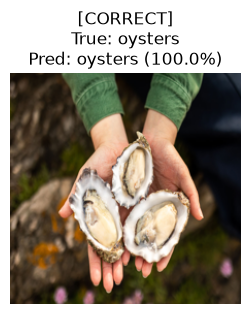

File: oysters_3.jpg
True Class: oysters
Top-3 Predictions:
  1. oysters                   100.00%
  2. clam_chowder              0.00%
  3. cannoli                   0.00%
--------------------------------------------------


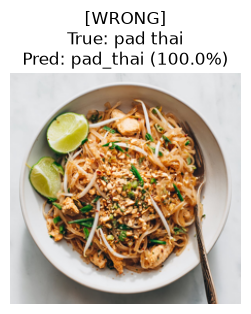

File: pad thai_3.jpg
True Class: pad thai
Top-3 Predictions:
  1. pad_thai                  99.99%
  2. fried_rice                0.00%
  3. bibimbap                  0.00%
--------------------------------------------------


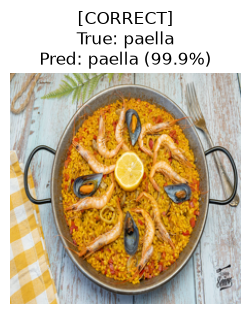

File: paella_4.jpg
True Class: paella
Top-3 Predictions:
  1. paella                    99.94%
  2. pizza                     0.04%
  3. oysters                   0.00%
--------------------------------------------------


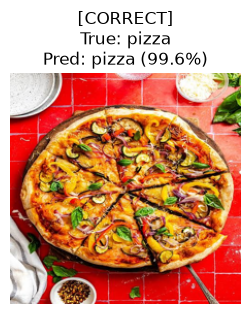

File: pizza_1.jpg
True Class: pizza
Top-3 Predictions:
  1. pizza                     99.65%
  2. paella                    0.28%
  3. apple_pie                 0.02%
--------------------------------------------------


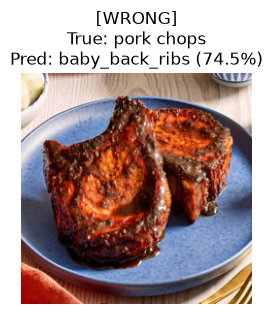

File: pork_chops_4.jpg
True Class: pork chops
Top-3 Predictions:
  1. baby_back_ribs            74.55%
  2. pork_chop                 9.34%
  3. french_toast              9.12%
--------------------------------------------------


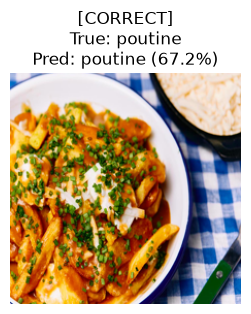

File: poutine_2.jpg
True Class: poutine
Top-3 Predictions:
  1. poutine                   67.16%
  2. nachos                    18.19%
  3. pad_thai                  4.73%
--------------------------------------------------


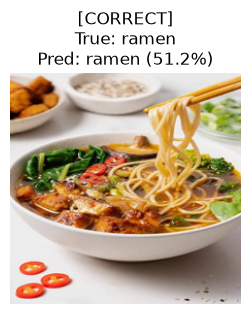

File: ramen_3.jpg
True Class: ramen
Top-3 Predictions:
  1. ramen                     51.18%
  2. pho                       45.89%
  3. spaghetti_bolognese       1.09%
--------------------------------------------------


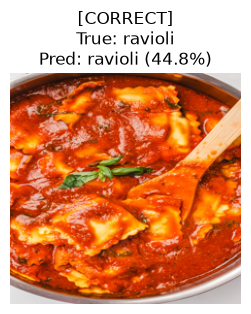

File: ravioli_3.jpg
True Class: ravioli
Top-3 Predictions:
  1. ravioli                   44.76%
  2. chicken_curry             29.93%
  3. lasagna                   13.00%
--------------------------------------------------


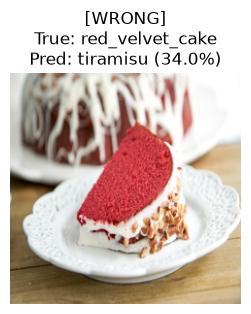

File: red_velvet_cake_3.jpg
True Class: red_velvet_cake
Top-3 Predictions:
  1. tiramisu                  34.03%
  2. red_velvet_cake           27.33%
  3. strawberry_shortcake      27.27%
--------------------------------------------------


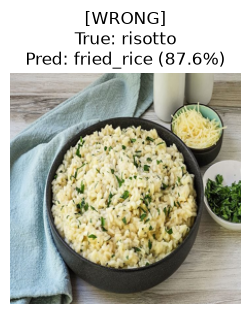

File: risotto_1.jpg
True Class: risotto
Top-3 Predictions:
  1. fried_rice                87.60%
  2. bibimbap                  7.81%
  3. macaroni_and_cheese       2.14%
--------------------------------------------------


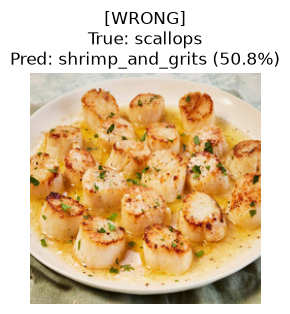

File: scallops_1.jpg
True Class: scallops
Top-3 Predictions:
  1. shrimp_and_grits          50.77%
  2. scallops                  30.07%
  3. gnocchi                   9.89%
--------------------------------------------------


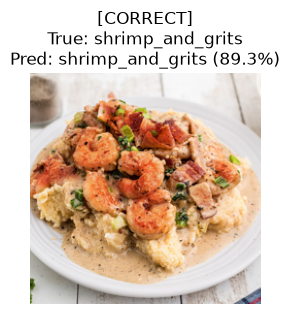

File: shrimp_and_grits_3.jpg
True Class: shrimp_and_grits
Top-3 Predictions:
  1. shrimp_and_grits          89.26%
  2. chicken_curry             7.83%
  3. ravioli                   0.93%
--------------------------------------------------


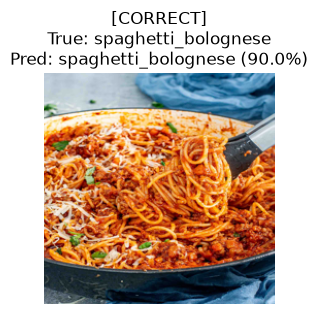

File: Spaghetti-Bolognese-3.jpg
True Class: spaghetti_bolognese
Top-3 Predictions:
  1. spaghetti_bolognese       90.05%
  2. bibimbap                  6.73%
  3. pad_thai                  1.72%
--------------------------------------------------


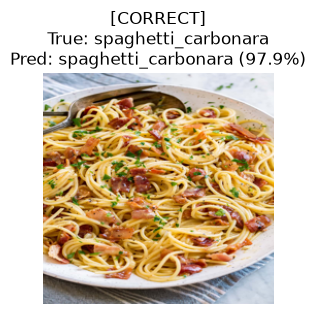

File: spaghetti-carbonara-1.jpg
True Class: spaghetti_carbonara
Top-3 Predictions:
  1. spaghetti_carbonara       97.87%
  2. spaghetti_bolognese       2.09%
  3. hot_dog                   0.01%
--------------------------------------------------


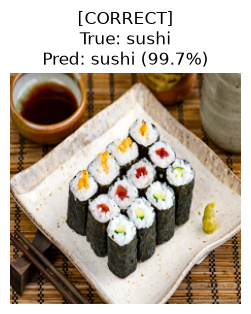

File: sushi_4.jpg
True Class: sushi
Top-3 Predictions:
  1. sushi                     99.65%
  2. oysters                   0.27%
  3. deviled_eggs              0.02%
--------------------------------------------------


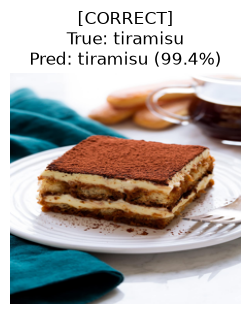

File: tiramisu-1.jpg
True Class: tiramisu
Top-3 Predictions:
  1. tiramisu                  99.44%
  2. grilled_cheese_sandwich   0.41%
  3. carrot_cake               0.07%
--------------------------------------------------


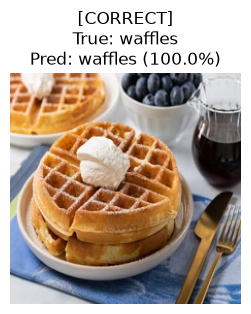

File: waffles_1.jpg
True Class: waffles
Top-3 Predictions:
  1. waffles                   99.99%
  2. pancakes                  0.01%
  3. apple_pie                 0.00%
--------------------------------------------------

Final Top-1 Prediction Accuracy: 31/40 (77.5%)


In [8]:
# Collect 1 test image from each of the 40 test class subfolders
sample_images = []

for class_dir in sorted(DATA_DIR.iterdir()):
    if class_dir.is_dir():
        images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png"))
        if images:
            sample_images.append(images[0])

print(f"Testing 1 sample image from each of the {len(sample_images)} test subfolders...\n")

correct_count = 0

for img_path in sample_images:
    img, top_preds = predict_image_top_k(img_path, k=3)
    true_class = img_path.parent.name  # Subfolder name is ground truth label

    top1_class, top1_conf = top_preds[0]
    is_correct = (top1_class == true_class)

    if is_correct:
        correct_count += 1

    status = "CORRECT" if is_correct else "WRONG"

    # Display image thumbnail with status and predictions
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"[{status}]\nTrue: {true_class}\nPred: {top1_class} ({top1_conf:.1%})")
    plt.show()

    # Print Top-3 class predictions
    print(f"File: {img_path.name}")
    print(f"True Class: {true_class}")
    print("Top-3 Predictions:")
    for rank, (c_name, prob) in enumerate(top_preds, 1):
        print(f"  {rank}. {c_name:<25} {prob:.2%}")
    print("-" * 50)

# Print summary accuracy score
accuracy = correct_count / len(sample_images) if sample_images else 0
print(f"\nFinal Top-1 Prediction Accuracy: {correct_count}/{len(sample_images)} ({accuracy:.1%})")

# 4: Full Dataset Evaluation Table (Per-Class & Overall Summary)

In [ ]:
# Collect ALL test images across all subfolders
all_images = list(DATA_DIR.rglob("*.jpg")) + list(DATA_DIR.rglob("*.png"))
print(f"Evaluating all {len(all_images)} images across all class subfolders...")

results = []

for img_path in all_images:
    # Direct folder name as ground truth class (matches model class format)
    true_class = img_path.parent.name

    # Run fast prediction without rendering images
    _, top_preds = predict_image_top_k(img_path, k=1)
    top1_class, top1_conf = top_preds[0]

    is_correct = (top1_class == true_class)

    results.append({
        "file_name": img_path.name,
        "true_class": true_class,
        "predicted_class": top1_class,
        "correct": is_correct
    })

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Group statistics by class
class_summary = (
    df_results.groupby("true_class")["correct"]
    .agg(total_images="count", correct_predictions="sum", accuracy="mean")
    .reset_index()
)

# Sort classes alphabetically
class_summary = class_summary.sort_values(by="true_class", ascending=True)

# Format accuracy as percentage
class_summary["accuracy_pct"] = class_summary["accuracy"].map("{:.1%}".format)

# Calculate overall statistics
total_all = class_summary["total_images"].sum()
correct_all = class_summary["correct_predictions"].sum()
overall_acc = correct_all / total_all if total_all > 0 else 0

# Append overall summary row at the bottom
total_row = pd.DataFrame([{
    "true_class": "--- TOTAL / OVERALL ---",
    "total_images": total_all,
    "correct_predictions": correct_all,
    "accuracy": overall_acc,
    "accuracy_pct": f"{overall_acc:.1%}"
}])

final_summary = pd.concat([class_summary, total_row], ignore_index=True)

# Display final summary table
display(final_summary[["true_class", "total_images", "correct_predictions", "accuracy_pct"]])

Evaluating all 150 images across all class subfolders...


,true_class,total_images,correct_predictions,accuracy_pct
0,apple_pie,6,2,33.3%
1,baby_back_ribs,4,3,75.0%
2,baklava,5,1,20.0%
3,beef_carpaccio,5,4,80.0%
4,beef_tartare,5,4,80.0%
5,bruschetta,3,2,66.7%
6,cannoli,3,2,66.7%
7,carrot_cake,4,4,100.0%
8,ceviche,3,2,66.7%
9,cheesecake,4,4,100.0%
